the objective of this project is to develop a ml based clasification model that predicts geopolitical state between countries. the model aims to classify relationship into multiple categories peace, strategic competations, coldwar, proxy war, direct war, based on factors such as military strength nuclear capabilities, economic condition, ideologcal differece, political stability, historical conflicts and senetiment analysis derieved from media and public scores, built and evaluate a neural network model using proper data processing validation and testing. optimise model parameters through hyperparemetere tuning and validation strategies.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


In [2]:
df=pd.read_csv("geopolitical_dataset.csv")
df.head()


,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637,1
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081,1
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622,1
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313,1
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333,1


In [5]:
df.describe()

,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.235385,49.160000,0.529000,253.442000,1.279245,4.597000,0.498373,0.497929,0.489480,4.496000,492.823847,-0.018263,0.517017,0.497426,1.595000
std,0.438206,29.131204,0.499408,143.414142,0.425925,2.844412,0.287361,0.289664,0.287191,2.930285,280.927662,0.570455,0.285276,0.295820,0.776903
min,0.506948,0.000000,0.000000,0.000000,0.500664,0.000000,0.000227,0.003918,0.000241,0.000000,0.052827,-0.999518,0.002141,0.000158,0.000000
25%,0.853960,24.000000,0.000000,130.750000,0.927437,2.000000,0.255222,0.245255,0.240101,2.000000,257.662524,-0.511212,0.280303,0.241523,1.000000
50%,1.245211,47.000000,1.000000,259.000000,1.296736,5.000000,0.483831,0.500748,0.481948,5.000000,490.355372,-0.011218,0.523833,0.484278,2.000000
75%,1.616479,75.000000,1.000000,380.250000,1.643959,7.000000,0.749492,0.745443,0.741773,7.000000,724.534469,0.471912,0.765292,0.762728,2.000000
max,1.999577,99.000000,1.000000,499.000000,1.999316,9.000000,0.998793,0.999461,0.999207,9.000000,996.990503,0.999010,0.999673,0.999335,4.000000


In [7]:
import matplotlib.pyplot as plt

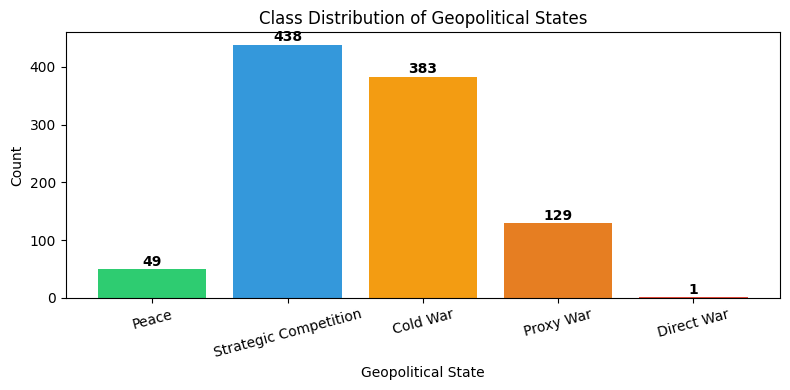

In [12]:
# # Class distribution
class_labels = {0: 'Peace', 1: 'Strategic Competition', 2: 'Cold War', 3: 'Proxy War', 4: 'Direct War'}

class_counts = df['target'].value_counts().sort_index()
mapped_labels = [class_labels.get(i, str(i)) for i in class_counts.index]

plt.figure(figsize=(8, 4))
bars = plt.bar(mapped_labels, class_counts.values, color=['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c'])
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Class Distribution of Geopolitical States')
plt.xlabel('Geopolitical State')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# data processing

In [13]:
# Separate features and target
X = df.drop('target', axis=1).values
y = df['target'].values

num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")
print(f"Classes found: {np.unique(y)}")

# One-hot encode target for neural network
y_cat = to_categorical(y, num_classes=num_classes)

# Train / Validation / Test split: 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Number of classes: 5
Classes found: [0 1 2 3 4]


NameError: name 'to_categorical' is not defined

In [ ]:
# model trainnig 
